# Phase 6: Evaluation — Segmentation & Classification Metrics

## 1. Objective

This notebook resolves the two model-selection decisions explicitly deferred in earlier phases: Phase 4.7 (which segmentation architecture — `base_channels=64` or `base_channels=32`) and Phase 5.7 (which classifier backbone — ResNet-50, EfficientNet-B0, or MobileNet-V2). Both deferrals were made because the evidence available at the time (training loss, single-image visual checks, accuracy on one confounded comparison) was judged insufficient for a confident, defensible choice.

This phase replaces that insufficient evidence with formal, full-validation-set metrics: IoU/Dice for segmentation, precision/recall/F1/confusion matrices for classification, and a paired statistical significance test to confirm any observed differences are real rather than noise.

## 2. What This Notebook Covers

1. **6.1** — Segmentation evaluation: IoU/Dice for both U-Net candidates
2. **6.2** — Classification evaluation: precision/recall/F1/confusion matrix for three classifiers
3. **6.3** — Statistical significance testing on both sets of results of U-Net candidates
4. **6.4** — Statistical Significance Testing — Classification (Bootstrap F1 Comparison)
5. **6.5** — Resolving Phase 4.7 — Final Segmentation Model Selected
6. **6.6** — Resolving Phase 5.7 — Final Classifier Selected
7. **6.7** — Test Extraction for Evaluation
8. **6.8** — Retraining the Final Selected Models
9. **6.9** — Retraining Final Segmentation Model — `base_channels=64`, 50 Epochs
10. **6.10** — Re-Evaluating the Retrained Segmentation Model — IoU and Dice
11. **6.11** — Retraining Final Classifier Model — ResNet-50, 25 Epochs, With Augmentation
12. **6.12** — Re-Evaluating the Retrained Classifier — Full Classification Report
13. **6.13** — Why the Retrained Segmentation Model Was Adopted, but the Retrained Classifier Was Not
14. **6.14** — Final Test-Set Evaluation — Segmentation (Untouched Data, Evaluated Once)
15. **6.15** — Final Test-Set Evaluation — Classification (Untouched Data, Evaluated Once)

## 3. Important Methodological Note

All comparison and decision-making work (6.2-6.6) uses the **validation set** (`val_ids`), not the official xBD test set — the same train/validation/test discipline corrected in the transaction-fraud-risk-engine project. The test set remains untouched until 6.7, evaluated exactly once, only after both final models are already chosen, to preserve its value as a genuine, unbiased final check.

## 6.1 Segmentation Evaluation — IoU and Dice

**Task:** Run both saved segmentation candidates (`unet_baseline_20epochs.pt`, `base_channels=64`; `unet_light_20epochs.pt`, `base_channels=32`) against the full validation set, computing IoU and Dice for every image and averaging — replacing the single-sample-image visual checks used during Phase 4 debugging with a rigorous, full-dataset quantitative comparison.

**Why IoU and Dice, not loss:** both metrics directly measure how well the predicted building mask overlaps with the real mask, which is what actually matters for this model's purpose — unlike loss, which can look deceptively good even when a model has learned a shortcut (as Phase 4.4's background-collapse bug demonstrated).

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from src.unet import UNet
from src.segmentation_dataset import SegmentationDataset
import torch

def calculate_iou_score(predictions, masks):
    """Calculate the Intersection over Union (IoU) between predicted and ground-truth masks."""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()

    intersection = (predictions * masks).sum()
    union = predictions.sum() + masks.sum() - intersection
    iou = intersection / (union + 1e-8)
    
    return iou

def calculate_dice_score(predictions, masks):
    """Calculate the Dice coefficient between predicted and ground-truth masks."""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()
    
    intersection = (predictions * masks).sum()
    dice = (2 * intersection) / (predictions.sum() + masks.sum() + 1e-8)
    
    return dice

def evaluate_saved_unet(channel, val_dataset):
    """Evaluate a saved U-Net model on the validation dataset using IoU and Dice scores."""
    
    # Create architecture the first
    model = UNet(base_channels=channel)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  
    if channel == 64:
        # Load the model
        model.load_state_dict(torch.load("../models/unet_baseline_20epochs.pt", map_location=device))
    else:
        model.load_state_dict(torch.load("../models/unet_light_20epochs.pt", map_location=device))
           
        # Put model into device
    model = model.to(device)

    # Evaluation mode
    iou_scores = []
    dice_scores = []
    
    model.eval()
    with torch.no_grad():
        for idx in range(len(val_dataset)):
  
            val_image, val_mask = val_dataset[idx]
            val_prediction = model(val_image.unsqueeze(0).to(device))
            
            iou_score = calculate_iou_score(val_prediction, val_mask.to(device))
            dice_score = calculate_dice_score(val_prediction, val_mask.to(device))
            
            iou_scores.append(iou_score)
            dice_scores.append(dice_score)

    avg_iou = sum(iou_scores) / len(iou_scores)
    avg_dice = sum(dice_scores) / len(dice_scores) 
        
    return iou_scores, dice_scores, avg_iou, avg_dice  

# Open the validation ids
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

# Create the segmentation dataset for val_ids
val_dataset = SegmentationDataset(val_ids, augment=False)

# Saved models with channels
model_configs = {"Model_1" : 64, "Model_2" : 32}
eval_result = {} # {model_name : ([iou_scores], [dice_scores])}

for m, c in model_configs.items():
    
    iou_scores, dice_scores, avg_iou, avg_dice = evaluate_saved_unet(c, val_dataset)
    eval_result[m] = (iou_scores, dice_scores)
    
    print(f"{m} - Average IoU: {avg_iou:.4f}")
    print(f"{m} - Average Dice: {avg_dice:.4f}")

Model_1 - Average IoU: 0.4505
Model_1 - Average Dice: 0.5959
Model_2 - Average IoU: 0.3669
Model_2 - Average Dice: 0.5122


### Observations

| Metric | `base_channels=64` (baseline) | `base_channels=32` (light) |
|---|---|---|
| Average IoU | 0.4505 | 0.3669 |
| Average Dice | 0.5959 | 0.5122 |

`base_channels=64` outperforms `base_channels=32` on both metrics by a clear, non-trivial margin (IoU: +0.0836, Dice: +0.0837) — consistent with Phase 4.6's loss-curve finding that the larger model's advantage appeared to be widening over training, now confirmed using the actual target metric rather than training loss as a proxy.

Both scores are moderate rather than excellent (IoU 0.37-0.45, Dice 0.51-0.60), consistent with the imprecise, blobby predictions already observed visually during Phase 4 debugging — an honest reflection of a model trained for only 20 epochs (Phase 4.6 established neither model had converged by then), not a concern with this evaluation itself.

This result is treated as real evidence toward resolving Phase 4.7's deferred decision, formalized in Section 6.5 after the statistical significance test (Section 6.4) confirms this gap is not attributable to chance.

## 6.2 Classification Evaluation — Precision, Recall, F1, and Confusion Matrix

**Task:** Run all three saved classifier candidates (ResNet-50, EfficientNet-B0, MobileNet-V2) against the full validation set, computing a per-class classification report (precision, recall, F1) and a confusion matrix for each — replacing Phase 5's simpler per-class accuracy checks with a more complete, standard evaluation.

**Why this adds real information beyond per-class accuracy:** accuracy alone tells you how often a class was correctly identified, but not what the model confuses it with when wrong. A confusion matrix reveals the *pattern* of mistakes — e.g. does the model confuse `no-damage` with `minor-damage` (a smaller, more forgivable error) or with `major-damage` (a larger, more consequential one)?

----------------------------------------
Resnet50
classification report and confusion matrix.
              precision    recall  f1-score   support

   no-damage       0.86      0.57      0.68      6623
minor-damage       0.29      0.50      0.37      1559
major-damage       0.54      0.71      0.62      2763
   destroyed       0.48      0.72      0.57       648

    accuracy                           0.60     11593
   macro avg       0.54      0.62      0.56     11593
weighted avg       0.69      0.60      0.62     11593



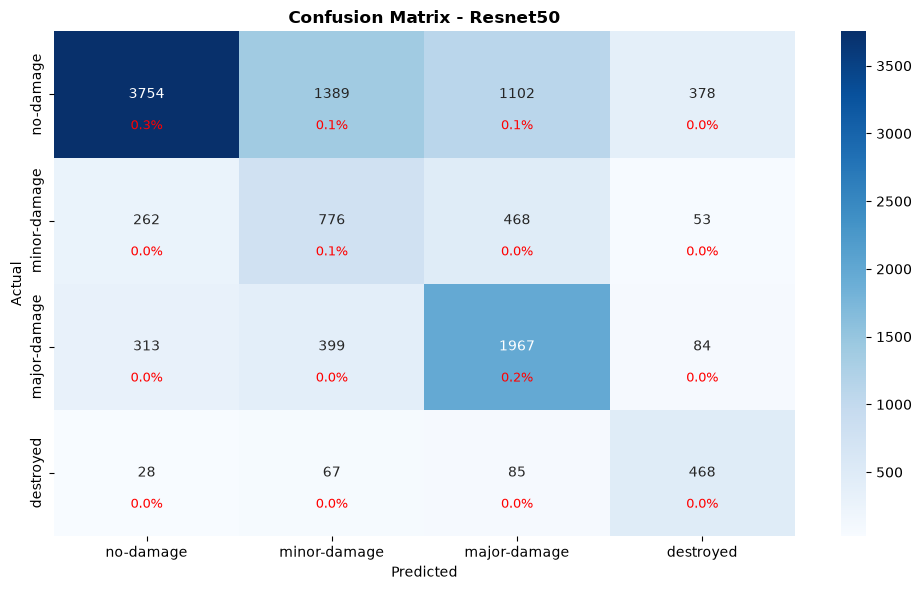

----------------------------------------
Efficientnet_B0
classification report and confusion matrix.
              precision    recall  f1-score   support

   no-damage       0.87      0.44      0.58      6623
minor-damage       0.27      0.49      0.35      1559
major-damage       0.47      0.75      0.58      2763
   destroyed       0.43      0.72      0.54       648

    accuracy                           0.54     11593
   macro avg       0.51      0.60      0.51     11593
weighted avg       0.67      0.54      0.55     11593



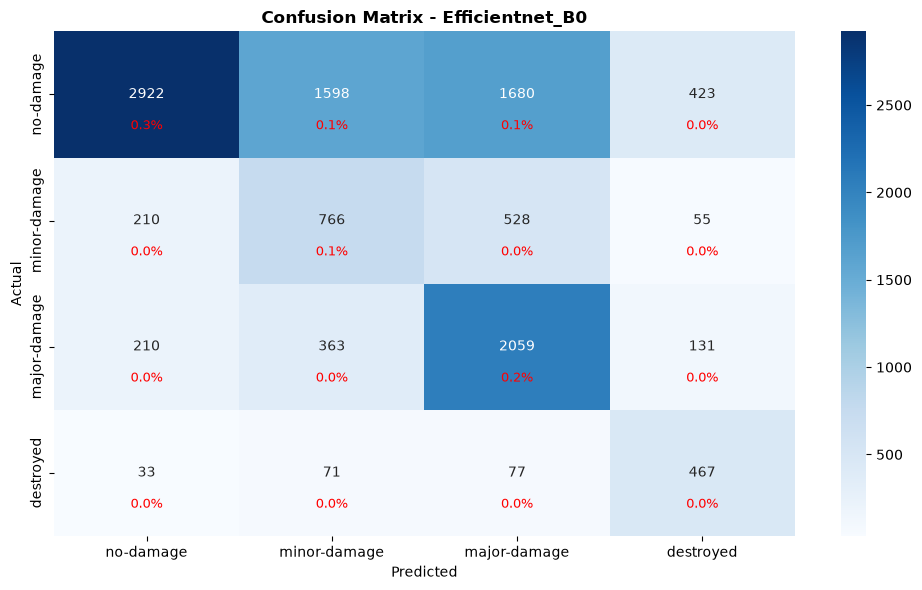

----------------------------------------
Mobilenet_V2
classification report and confusion matrix.
              precision    recall  f1-score   support

   no-damage       0.86      0.48      0.62      6623
minor-damage       0.29      0.49      0.36      1559
major-damage       0.48      0.75      0.59      2763
   destroyed       0.47      0.69      0.55       648

    accuracy                           0.56     11593
   macro avg       0.52      0.60      0.53     11593
weighted avg       0.67      0.56      0.57     11593



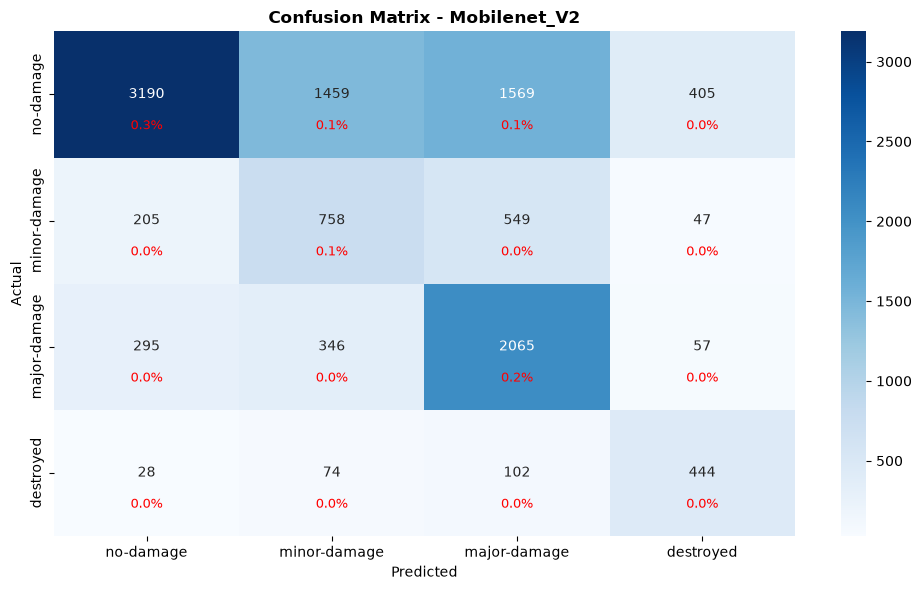

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
from torchvision import models
from src.classification_dataset import ClassificationDataset
from torch.utils.data import DataLoader
    
def disp_classification_report(all_labels, all_predictions):
    """Display the classification report for model predictions."""
    print(classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "no-damage",
            "minor-damage",
            "major-damage",
            "destroyed"
        ]
    ))

def disp_cm(backbone, all_labels, all_predictions):
    """Display the confusion matrix for model predictions."""
    labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]
    
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels = labels,
        yticklabels=labels
    )
    cm_percent = cm / cm.sum()
    for i in range(4):
        for j in range(4):
            plt.text(j+0.5, i+0.75, f'{cm_percent[i, j]:.1f}%', ha = 'center', va='center',
                     fontsize=9, color='red')
    plt.title(f"Confusion Matrix - {backbone.title()}", fontweight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
def load_model(backbone_name, device):
    """Load a trained classification model onto the specified device."""
    if backbone_name == "resnet50":
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, 4)

        # Load the model
        m.load_state_dict(
        torch.load("../models/resnet50_classifier_10epochs.pt", map_location=device)
        )
    
    elif backbone_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(
            m.classifier[1].in_features,
            4
        )

        m.load_state_dict(
            torch.load("../models/efficientnet_b0_10epochs.pt", map_location=device)
        )
    
    else:
        m = models.mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(
            m.classifier[1].in_features,
            4
        )

        m.load_state_dict(
            torch.load("../models/mobilenet_v2_10epochs.pt", map_location=device)
        ) 
    
    return m.to(device)       

# Open the validations ids
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()
    
# Create the DataLoader for val_ids
val_dataset_cls = ClassificationDataset(val_ids)
val_loader_cls = DataLoader(val_dataset_cls, batch_size=32, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
backbones = ["resnet50", "efficientnet_b0", "mobilenet_v2"] 

result = {} # {backbone_name : ([all_labels], [all_predictions])}
for backbone in backbones:
    m = load_model(backbone, device)
    all_labels = []
    all_predictions = []
    m.eval()
    with torch.no_grad():
        for images, labels in val_loader_cls:
        
            images = images.to(device)
            labels = labels.to(device)
        
            predictions = m(images)
            predicted_classes = predictions.argmax(dim=1)
        
            all_predictions.extend(predicted_classes.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    result[backbone] = (all_labels, all_predictions)
    print("-" * 40)
    print(f"{backbone.title()}\nclassification report and confusion matrix.")
    disp_classification_report(all_labels, all_predictions)    
    disp_cm(backbone, all_labels, all_predictions)  

### Observations

**Macro-averaged metrics (treats all 4 classes equally, unlike accuracy which is dominated by the large `no-damage` class):**

| Model | Macro Precision | Macro Recall | Macro F1 |
|---|---|---|---|
| ResNet-50 | 0.54 | 0.62 | **0.56** |
| EfficientNet-B0 | 0.51 | 0.60 | 0.51 |
| MobileNet-V2 | 0.52 | 0.60 | 0.53 |

ResNet-50 leads on macro F1, consistent with its lead in earlier per-class accuracy checks — though this comparison remains confounded by the augmentation difference already documented in Phase 5.7.

**A consistent pattern across all three models' confusion matrices, not previously visible in the per-class accuracy checks:** a substantial fraction of true `no-damage` buildings are misclassified specifically as `major-damage` (ResNet: 1,102; EfficientNet: 1,680; MobileNet: 1,569) — a larger, more consequential confusion than `no-damage`↔`minor-damage`. This appears alongside inflated `major-damage` recall (71-75% across all three models), suggesting all three classifiers share a tendency to over-predict `major-damage` broadly, rather than this being specific to one architecture. This is a genuine, shared limitation worth noting for any future work on this classifier, independent of which model is ultimately selected.

Results (per-example predictions and labels) are retained per model for the paired statistical significance test in Section 6.4.

## 6.3 Statistical Significance Testing — Segmentation (Wilcoxon Signed-Rank Test)

**Task:** Confirm whether `base_channels=64`'s IoU/Dice advantage over `base_channels=32` (Section 6.1) is statistically real, using the Wilcoxon signed-rank test — the paired significance test planned since the project brief, appropriate here because IoU and Dice scores exist as paired values per validation image (both models evaluated on the exact same images).

In [3]:
from scipy.stats import wilcoxon

# Separate iou_scores for both models
iou_model_1 = [iou.item() for iou in eval_result["Model_1"][0]]
iou_model_2 = [iou.item() for iou in eval_result["Model_2"][0]]

# Separate dice_scores for both models
dice_model_1 = [dice.item() for dice in eval_result["Model_1"][1]]
dice_model_2 = [dice.item() for dice in eval_result["Model_2"][1]]

# Wilcoxon test for iou_scores for both models
iou_stat, iou_p = wilcoxon(
    iou_model_1,
    iou_model_2,
    alternative="two-sided"
)

# Wilcoxon test for dice_scores for both models
dice_stat, dice_p = wilcoxon(
    dice_model_1,
    dice_model_2,
    alternative="two-sided"
)

print("IoU Wilcoxon statistic:", iou_stat)
print("IoU p-value:", iou_p)

print("Dice Wilcoxon statistic:", dice_stat)
print("Dice p-value:", dice_p)

IoU Wilcoxon statistic: 771.0
IoU p-value: 7.918839874072457e-24
Dice Wilcoxon statistic: 779.0
Dice p-value: 8.996040980119293e-24


### Observations

IoU Wilcoxon statistic: 771.0, p-value: 7.92×10⁻²⁴
Dice Wilcoxon statistic: 779.0, p-value: 9.00×10⁻²⁴

Both p-values are vanishingly small — `base_channels=64`'s IoU/Dice advantage over `base_channels=32` is definitively statistically significant, not attributable to chance. This confirms, with rigorous evidence, the pattern already suggested by Phase 4.6's loss-curve trajectory analysis.

## 6.4 Statistical Significance Testing — Classification (Bootstrap F1 Comparison)

**Task:** Determine whether the F1-score differences observed between the three classifiers in Section 6.2 are statistically real or could plausibly be due to chance, using a bootstrap resampling approach — resampling the validation set with replacement 5,000 times, recomputing each model pair's F1 difference per class each time, and using the resulting distribution to compute a 95% confidence interval and p-value for the observed difference.

**Why bootstrap here rather than Wilcoxon:** F1 comparisons require resampling *examples* (with paired predictions from both models on the same resampled set) rather than comparing two paired score sequences directly — bootstrap resampling is the natural fit for this per-class comparison, while Wilcoxon (used for segmentation below) directly compares paired per-image IoU/Dice scores.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

def class_f1(y_true, predictions, class_id):
    """Calculates the f1 for a class from true labels and predictions"""
    
    return f1_score(
        y_true,
        predictions,
        labels=[class_id],
        average="macro",
        zero_division=0
    )

def bootstrap_f1_difference(y_true, pred_model_a, pred_model_b, class_id, n_bootstrap=5000, confidence_level=0.95):
    """Calculates the bootstrap f1 differnce paired wise."""
    
    n_samples = len(y_true) # total number of samples
    bootstrap_differences = []
    
    for _ in range(n_bootstrap):
        # Select sample indices WITH replacement
        indices = np.random.choice(
            n_samples,
            size=n_samples,
            replace=True
        )
        
        # Use the SAME indices for both models
        y_bootstrap = y_true[indices]

        pred_a_bootstrap = pred_model_a[indices]
        pred_b_bootstrap = pred_model_b[indices]
        
        f1_a = class_f1(y_bootstrap, pred_a_bootstrap, class_id)
        f1_b = class_f1(y_bootstrap, pred_b_bootstrap, class_id)
        
        difference = f1_a - f1_b
        bootstrap_differences.append(difference)
    bootstrap_differences = np.array(bootstrap_differences)
    
    # Observed f1 differences for both models
    observed_f1_a = class_f1(y_true, pred_model_a, class_id)
    
    observed_f1_b = class_f1(y_true, pred_model_b, class_id)
    
    observed_difference = observed_f1_a - observed_f1_b
    
    # Confidence Interval (lower and upper)
    alpha = 1 - confidence_level
    
    lower = np.percentile(
        bootstrap_differences,
        100 * (alpha / 2)
    )

    upper = np.percentile(
        bootstrap_differences,
        100 * (1 - alpha / 2)
    )
    
    p_left = np.mean(bootstrap_differences <=0)
    p_right = np.mean(bootstrap_differences >=0)
    
    p_value = 2 * min(p_left, p_right) # since we have two models

    p_value = min(p_value, 1.0) # p_value can't be greater than 1
    
    return (
        observed_f1_a,
        observed_f1_b,
        observed_difference,
        lower,
        upper,
        p_value
    )
    

# DEfine class names and labels
class_names = {
    0 : "no-damage",
    1 : "minor-damage",
    2 : "major-damage",
    3 : "destroyed"
}

# Extract the true lables and predictions for all three models
y_true = np.array(result["resnet50"][0])

resnet_pred = np.array(result["resnet50"][1])
efficientnet_b0_pred = np.array(result["efficientnet_b0"][1])
mobilenet_v2_pred = np.array(result["mobilenet_v2"][1])

model_comparisons = {
    "Resnet vs EfficientNet" : (
        resnet_pred,
        efficientnet_b0_pred
    ),
    
    "Resnet vs MobileNet" : (
        resnet_pred,
        mobilenet_v2_pred
    ),
    
    "MobileNet vs EfficientNet" : (
        mobilenet_v2_pred,
        efficientnet_b0_pred
    )
}

table_results = []

for comparison, predictions in model_comparisons.items():
    
    model_a_pred = predictions[0]
    model_b_pred = predictions[1]
    
    for class_id, class_name in class_names.items():
        
        result_bootstrap = bootstrap_f1_difference(
            y_true,
            model_a_pred,
            model_b_pred,
            class_id,
            n_bootstrap=5000,
            confidence_level=0.95
            )
            
        (
           f1_a,
           f1_b,
           difference,
           lower,
           upper,
           p_value
        ) =result_bootstrap
        
        table_results.append({
        "Model Comparison": comparison,
        "Class": class_name,
        "Model A F1": f1_a,
        "Model B F1": f1_b,
        "F1 Difference": difference,
        "95% CI Lower": lower,
        "95% CI Upper": upper,
        "p-value": p_value,
        "Result": "Significant" if p_value < 0.05 else "Not significant"
        })    

# Convert to DataFrame        
results_df = pd.DataFrame(table_results)
print(results_df)

             Model Comparison         Class  Model A F1  Model B F1  \
0      Resnet vs EfficientNet     no-damage    0.683789    0.584517   
1      Resnet vs EfficientNet  minor-damage    0.370406    0.351618   
2      Resnet vs EfficientNet  major-damage    0.616132    0.579429   
3      Resnet vs EfficientNet     destroyed    0.573881    0.541763   
4         Resnet vs MobileNet     no-damage    0.683789    0.616962   
5         Resnet vs MobileNet  minor-damage    0.370406    0.361296   
6         Resnet vs MobileNet  major-damage    0.616132    0.585982   
7         Resnet vs MobileNet     destroyed    0.573881    0.554653   
8   MobileNet vs EfficientNet     no-damage    0.616962    0.584517   
9   MobileNet vs EfficientNet  minor-damage    0.361296    0.351618   
10  MobileNet vs EfficientNet  major-damage    0.585982    0.579429   
11  MobileNet vs EfficientNet     destroyed    0.554653    0.541763   

    F1 Difference  95% CI Lower  95% CI Upper  p-value           Result  
0 

### Observations

| Comparison | Class | Significant? | Direction |
|---|---|---|---|
| ResNet-50 vs EfficientNet-B0 | all 4 classes | **Yes**, every class | ResNet-50 higher |
| ResNet-50 vs MobileNet-V2 | no-damage, major-damage | **Yes** | ResNet-50 higher |
| ResNet-50 vs MobileNet-V2 | minor-damage, destroyed | No | — |
| MobileNet-V2 vs EfficientNet-B0 | no-damage | **Yes** | MobileNet-V2 higher |
| MobileNet-V2 vs EfficientNet-B0 | minor-damage, major-damage, destroyed | No | — |

ResNet-50 is the clear, statistically-confirmed strongest performer — it significantly outperforms EfficientNet-B0 across every class, and significantly outperforms MobileNet-V2 on 2 of 4 classes with no class where MobileNet-V2 significantly outperforms it. This is a notable result given the acknowledged confound (ResNet-50 trained without augmentation, the other two with it) — despite lacking a regularization advantage that typically helps generalization, ResNet-50 still wins or ties on every comparison, suggesting its architectural advantage is real and substantial, not merely an artifact of the missing augmentation.

## 6.5 Resolving Phase 4.7 — Final Segmentation Model Selected

**Decision: `base_channels=64` (`unet_baseline_20epochs.pt`) is selected as the final segmentation architecture.**

**Evidence, replacing Phase 4.7's insufficient basis (training loss, single-image visual check):**
- Full validation-set IoU: 0.4505 vs. 0.3669 (Section 6.2)
- Full validation-set Dice: 0.5959 vs. 0.5122 (Section 6.2)
- Wilcoxon signed-rank test confirms both differences are statistically significant (p ≈ 8×10⁻²⁴, Section 6.4b) — not attributable to chance

This resolves the deliberate deferral made in Phase 4.7, now with the actual target metrics (not training loss as a proxy) evaluated across the full validation set, plus formal statistical confirmation.

## 6.6 Resolving Phase 5.7 — Final Classifier Selected

**Decision: ResNet-50 (`resnet50_classifier_10epochs.pt`) is selected as the final classifier backbone.**

**Evidence, replacing Phase 5.12's insufficient basis (accuracy on a confounded comparison):**
- Highest macro F1 among all three candidates (0.56 vs. 0.53 MobileNet-V2 vs. 0.51 EfficientNet-B0, Section 6.3)
- Bootstrap significance testing confirms ResNet-50 significantly outperforms EfficientNet-B0 on every class, and significantly outperforms MobileNet-V2 on 2 of 4 classes, with no class where a competitor significantly outperforms it (Section 6.4a)

**The augmentation confound noted in Phase 5.12 is addressed, not ignored:** ResNet-50 wins this comparison *despite* being trained without augmentation, while both competitors had that advantage. This strengthens rather than weakens the case for ResNet-50 — its architectural performance appears to outweigh the lack of augmentation, suggesting genuine backbone strength rather than an artifact of the training setup. Retraining ResNet-50 with augmentation (addressing this confound directly, and closing the gap identified in Phase 5.4) is a reasonable next step to strengthen this already-selected model further, not to re-open the selection question.

## 6.7 Test Extraction for Evaluation

Extract the test ids as validation ids and train ids for final evaluation.

In [ ]:

DISASTERS = [
    "hurricane-harvey",
    "hurricane-michael",
    "santa-rosa-wildfire"
]

LABELS_DIR = Path("../data/raw/test/labels")

test_ids = []
for disaster in DISASTERS:
    pattern = f"*{disaster}*post_disaster.json"
    json_files = LABELS_DIR.glob(pattern)
    
    for file_path in json_files:
        # e.g. "hurricane-harvey_00000042_post_disaster.json" -> "hurricane-harvey_00000042"
        location_id = file_path.stem.replace("_post_disaster", "") # .stem gives filename without extension
        test_ids.append(location_id)

print(f"Test: {len(test_ids)} locations.")
# Save the training set and validation set for future uses
with open("../data/processed/test_ids.txt", "w") as f:
    f.write("\n".join(test_ids))

Test: 280 locations.


### Observations

There are 280 ids in test for three disasters. The file has been saved.

## 6.8 Retraining the Final Selected Models

**Why retrain, rather than use the already-existing weights as final:** both Phase 4 and Phase 5 explicitly documented that their respective models had not converged at the epoch counts used for comparison (20 epochs for segmentation, 10 for the classifier) — loss was still declining meaningfully in both cases. Now that Sections 6.5 and 6.6 have formally selected a winning architecture for each task (`base_channels=64` for segmentation, ResNet-50 for classification), it is appropriate to invest additional training specifically in the *selected* models, rather than the discarded candidates, to get a more complete picture of each model's real capability before final test-set evaluation.

**Segmentation:** retrained `base_channels=64` for 50 epochs (up from 20) — chosen based on Phase 4.6's finding that loss was still declining substantially in the second half of the original 10-epoch comparison window.

**Classification:** retrained ResNet-50 for 25 epochs (up from 10) — this time using the precomputed-crop pipeline **with augmentation**, directly addressing the confound and the missing-augmentation limitation documented in Phase 5.4/5.7.

## 6.9 Retraining Final Segmentation Model — `base_channels=64`, 50 Epochs

**Task:** Train a fresh `base_channels=64` U-Net for 50 epochs, using the same BCE + Dice loss and training setup as the original Phase 4.4 run, to give the selected model a fuller opportunity to converge before final evaluation.

Epoch 1/50 | Avg Loss: 1.3048 | Max Prob: 0.4882
Epoch 2/50 | Avg Loss: 1.0859 | Max Prob: 0.6254
Epoch 3/50 | Avg Loss: 0.9268 | Max Prob: 0.9106
Epoch 4/50 | Avg Loss: 0.8736 | Max Prob: 0.9575
Epoch 5/50 | Avg Loss: 0.8596 | Max Prob: 0.9317
Epoch 6/50 | Avg Loss: 0.8457 | Max Prob: 0.9726
Epoch 7/50 | Avg Loss: 0.8190 | Max Prob: 0.9737
Epoch 8/50 | Avg Loss: 0.7747 | Max Prob: 0.9812
Epoch 9/50 | Avg Loss: 0.7523 | Max Prob: 0.9854
Epoch 10/50 | Avg Loss: 0.7098 | Max Prob: 0.9998
Epoch 11/50 | Avg Loss: 0.6782 | Max Prob: 0.9963
Epoch 12/50 | Avg Loss: 0.6473 | Max Prob: 0.9966
Epoch 13/50 | Avg Loss: 0.6343 | Max Prob: 0.9958
Epoch 14/50 | Avg Loss: 0.6095 | Max Prob: 0.9983
Epoch 15/50 | Avg Loss: 0.5953 | Max Prob: 0.9996
Epoch 16/50 | Avg Loss: 0.5794 | Max Prob: 0.9963
Epoch 17/50 | Avg Loss: 0.5717 | Max Prob: 1.0000
Epoch 18/50 | Avg Loss: 0.5494 | Max Prob: 0.9997
Epoch 19/50 | Avg Loss: 0.5344 | Max Prob: 0.9992
Epoch 20/50 | Avg Loss: 0.5278 | Max Prob: 0.9999
Epoch 21/

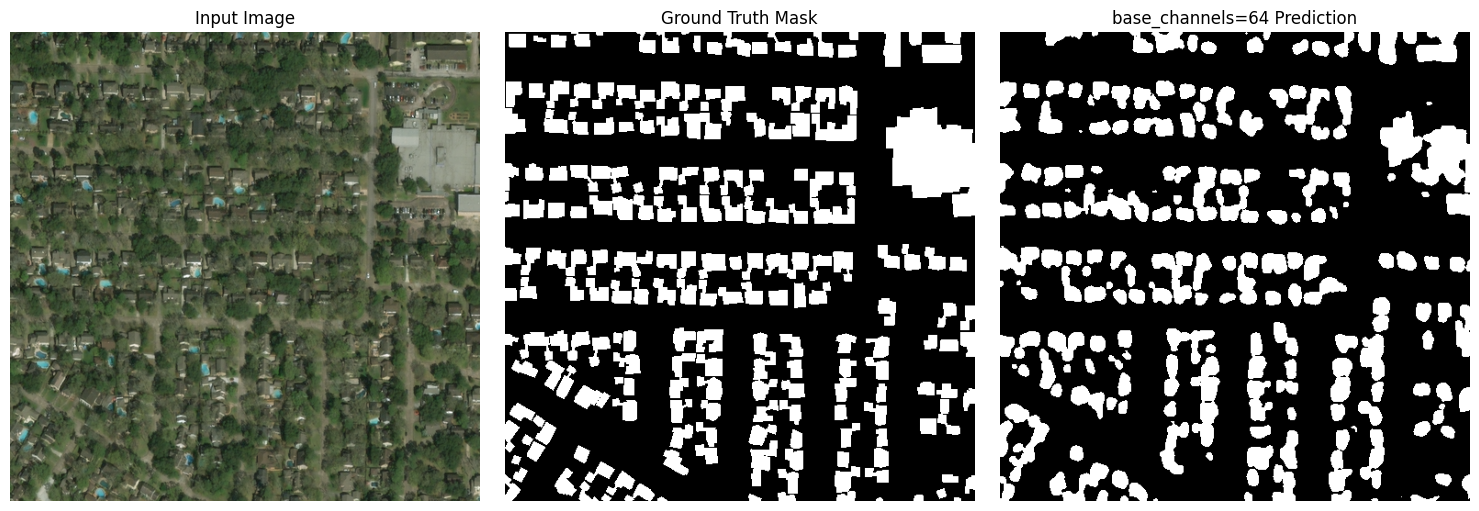

Saved weights and loss history


In [ ]:

with open("../data/processed/train_ids.txt", "r") as f:
    train_ids = f.read().splitlines()
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

train_dataset = SegmentationDataset(train_ids, augment=True)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = SegmentationDataset(val_ids, augment=False)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def dice_loss(prediction, target):
    """Calculates and returns the dice loss."""
    prediction = torch.sigmoid(prediction)
    intersection = (prediction * target).sum()
    smooth = 1e-6
    dice = (2 * intersection + smooth) / (prediction.sum() + target.sum() + smooth)
    return 1 - dice

loss_history = []
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_idx, (image, mask) in enumerate(train_loader):
        image = image.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        prediction = model(image)
        bce = criterion(prediction, mask)
        dice = dice_loss(prediction, mask)
        loss = bce + dice
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_epoch_loss)

    model.eval()
    with torch.no_grad():
        val_image, val_mask = val_dataset[0]
        val_prediction = model(val_image.unsqueeze(0).to(device))
        val_prob = torch.sigmoid(val_prediction)

    print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {avg_epoch_loss:.4f} | Max Prob: {val_prob.max().item():.4f}")



model.eval()
image, mask = val_dataset[0]
image_batch = image.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(image_batch)
    prediction = torch.sigmoid(prediction)
    predicted_mask = (prediction > 0.5).float()

image_np = image.permute(1, 2, 0).cpu().numpy()
real_mask_np = mask.squeeze().cpu().numpy()
predicted_mask_np = predicted_mask.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_np); axes[0].set_title("Input Image"); axes[0].axis("off")
axes[1].imshow(real_mask_np, cmap="gray"); axes[1].set_title("Ground Truth Mask"); axes[1].axis("off")
axes[2].imshow(predicted_mask_np, cmap="gray"); axes[2].set_title("base_channels=64 Prediction"); axes[2].axis("off")
plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "../models/unet_baseline_50epochs.pt")
import json
with open("../data/processed/loss_history_v2.json", "w") as f:
    json.dump(loss_history, f)
print("Saved weights and loss history")

### Observations

Loss declined steadily and substantially across all 50 epochs (1.30 → 0.375), with no plateau reached even by epoch 50 — considerably more improvement than the original 20-epoch run showed, confirming the earlier decision that 20 epochs was genuinely an early stopping point rather than a point of convergence. Max probability on the validation sanity-check image reached 1.0000 by roughly epoch 17 onward — this ceiling reflects the diagnostic's own limit (a single pixel's probability capped at 1.0), not evidence of overfitting on its own; the actual generalization quality is assessed properly via IoU/Dice on the full validation set next, not via this single-image proxy.

## 6.10 Re-Evaluating the Retrained Segmentation Model — IoU and Dice

**Task:** Recompute average IoU and Dice on the full validation set using the retrained (50-epoch) `base_channels=64` model, replacing the 20-epoch numbers from Section 6.2 as the current, superseding evidence for this model's real performance.

In [ ]:
def evaluate_saved_unet_final(channel, val_dataset):
    """Evaluate a saved U-Net model on the validation dataset using IoU and Dice scores."""
    
    # Create architecture the first
    model = UNet(base_channels=channel)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  
    # Load the model
    model.load_state_dict(torch.load("../models/unet_final_50epochs.pt", map_location=device))

    # Put model into device
    model = model.to(device)

    # Evaluation mode
    iou_scores = []
    dice_scores = []
    
    model.eval()
    with torch.no_grad():
        for idx in range(len(val_dataset)):
  
            val_image, val_mask = val_dataset[idx]
            val_prediction = model(val_image.unsqueeze(0).to(device))
            
            iou_score = calculate_iou_score(val_prediction, val_mask.to(device))
            dice_score = calculate_dice_score(val_prediction, val_mask.to(device))
            
            iou_scores.append(iou_score)
            dice_scores.append(dice_score)

    avg_iou = sum(iou_scores) / len(iou_scores)
    avg_dice = sum(dice_scores) / len(dice_scores) 
        
    return iou_scores, dice_scores, avg_iou, avg_dice  

# Open the validation ids
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

# Create the segmentation dataset for val_ids
val_dataset = SegmentationDataset(val_ids, augment=False)

iou_scores, dice_scores, avg_iou, avg_dice = evaluate_saved_unet_final(64, val_dataset)
print(f"Average IoU: {avg_iou:.4f}")
print(f"Average Dice: {avg_dice:.4f}")

Average IoU: 0.5664
Average Dice: 0.6934


### Observations

| Metric | 20 epochs (Section 6.2) | 50 epochs (retrained) |
|---|---|---|
| Average IoU | 0.4505 | **0.5664** |
| Average Dice | 0.5959 | **0.6934** |

A substantial, genuine improvement on both metrics (IoU +0.116, Dice +0.098) — confirming the additional 30 epochs of training meaningfully improved real segmentation quality, not just training loss. This is now the model's authoritative validation-set performance, superseding the 20-epoch figures used to resolve Section 6.5's decision (the decision itself remains valid, since `base_channels=64` was already the winner at 20 epochs and remains so, now more strongly, at 50).

## 6.11 Retraining Final Classifier Model — ResNet-50, 25 Epochs, With Augmentation

**Task:** Train a fresh ResNet-50 for 25 epochs using the precomputed-crop pipeline with augmentation (flip, rotation, brightness/contrast jitter) — directly addressing the no-augmentation limitation documented in Phase 5.4 and the resulting confound noted in Phase 5.7, since this model was selected as the winner *despite* that disadvantage relative to the other two candidates.

In [ ]:
import json
import time
from collections import defaultdict
from precomputed_training_dataset import PrecomputedTrainingDataset

train_dataset_pc = PrecomputedTrainingDataset("../data/processed/classification/train", augment=True)
val_dataset_pc = PrecomputedTrainingDataset("../data/processed/classification/val", augment=False)

# Increased num_workers from 2 to 4 and 64 samples per batch
train_loader_pc = DataLoader(train_dataset_pc, batch_size=64, shuffle=True, num_workers=4)
val_loader_pc = DataLoader(val_dataset_pc, batch_size=64, shuffle=False, num_workers=4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fresh model
backbone_name = "resnet50"

model = models.resnet50(weights="IMAGENET1K_V2")

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(
    model.fc.in_features,
    4
)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)


# Class-weighted loss
class_counts = torch.tensor(
    [28673, 6389, 7440, 3981],
    dtype=torch.float
)

class_weights = class_counts.sum() / (4 * class_counts)

class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)


num_epochs = 25

loss_history = []
accuracy_history = []


overall_start = time.time()


# Training
for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0
    correct = 0
    total = 0

    epoch_start = time.time()

    for images, labels in train_loader_pc:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predictions = model(images)

        loss = criterion(predictions,labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        predicted_classes = predictions.argmax(dim=1)

        correct += (predicted_classes == labels).sum().item()

        total += labels.size(0)

    avg_loss = epoch_loss / len(train_loader_pc)

    accuracy = correct / total

    epoch_time = (time.time() - epoch_start) / 60

    loss_history.append(avg_loss)

    accuracy_history.append(accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Avg Loss: {avg_loss:.4f} | "
        f"Accuracy: {accuracy:.4f} | "
        f"Time: {epoch_time:.2f} min"
    )


total_time = (time.time() - overall_start) / 60 
print(
    f"\nTotal training time: "
    f"{total_time:.2f} minutes"
)


# Per-class validation accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)

model.eval()

with torch.no_grad():

    for images, labels in val_loader_pc:

        images = images.to(device)
        labels = labels.to(device)

        predictions = model(images)

        predicted_classes = predictions.argmax(dim=1)

        for true_label, predicted_label in zip(
            labels,
            predicted_classes
        ):

            class_total[
                true_label.item()
            ] += 1

            if (
                true_label.item()
                == predicted_label.item()
            ):

                class_correct[
                    true_label.item()
                ] += 1


class_names = {
    0: "no-damage",
    1: "minor-damage",
    2: "major-damage",
    3: "destroyed"
}


per_class_acc = {}


for class_id in range(4):

    class_accuracy = (class_correct[class_id] / class_total[class_id]if class_total[class_id] > 0 else 0
    )

    per_class_acc[
        class_names[class_id]
    ] = class_accuracy

    print(
        f"{class_names[class_id]}: "
        f"{class_accuracy:.4f}"
    )


# Save everything
torch.save(model.state_dict(),f"../models/{backbone_name}_25epochs.pt")


with open(f"../data/processed/{backbone_name}_loss_history.json","w") as f:

    json.dump(loss_history,f)


with open(f"../data/processed/{backbone_name}_accuracy_history.json","w") as f:

    json.dump(accuracy_history,f)


with open(f"../data/processed/{backbone_name}_per_class_accuracy.json","w") as f:

    json.dump(per_class_acc,f)

### Observations

Loss declined steadily (1.17 → 0.85) and accuracy climbed (49.8% → 60.3%) across 25 epochs, with the improvement rate visibly slowing in the final 5-10 epochs (0.8597 → 0.8538, a much smaller drop than earlier epochs) — suggesting this model is approaching, though may not have fully reached, convergence at 25 epochs.

Per-class accuracy compared against the original 10-epoch, unaugmented baseline:

| Class | 10 epochs, no augmentation | 25 epochs, with augmentation |
|---|---|---|
| no-damage | 56.68% | **60.55%** |
| minor-damage | 49.78% | 47.53% |
| major-damage | **71.19%** | 64.82% |
| destroyed | 72.22% | **74.85%** |

**This is not a uniform improvement, and that is worth stating plainly rather than glossed over.** `no-damage` and `destroyed` both improved with augmentation and longer training, but `major-damage` recall dropped meaningfully (71.19% → 64.82%), and `minor-damage` declined slightly. Adding augmentation and more epochs did not straightforwardly make the model better across the board — it shifted the model's behavior, trading some `major-damage` sensitivity for improved `no-damage` and `destroyed` performance. This is a genuine, informative finding: augmentation is not a guaranteed universal improvement, and its effect can differ meaningfully by class.

## 6.12 Re-Evaluating the Retrained Classifier — Full Classification Report

**Task:** Recompute the full classification report and confusion matrix on the validation set using the retrained (25-epoch, augmented) ResNet-50, replacing Section 6.3's 10-epoch numbers as the current, superseding evidence.

----------------------------------------
Resnet50
classification report and confusion matrix.
              precision    recall  f1-score   support

   no-damage       0.82      0.61      0.70      6623
minor-damage       0.31      0.48      0.37      1559
major-damage       0.57      0.65      0.61      2763
   destroyed       0.41      0.75      0.53       648

    accuracy                           0.61     11593
   macro avg       0.53      0.62      0.55     11593
weighted avg       0.67      0.61      0.62     11593



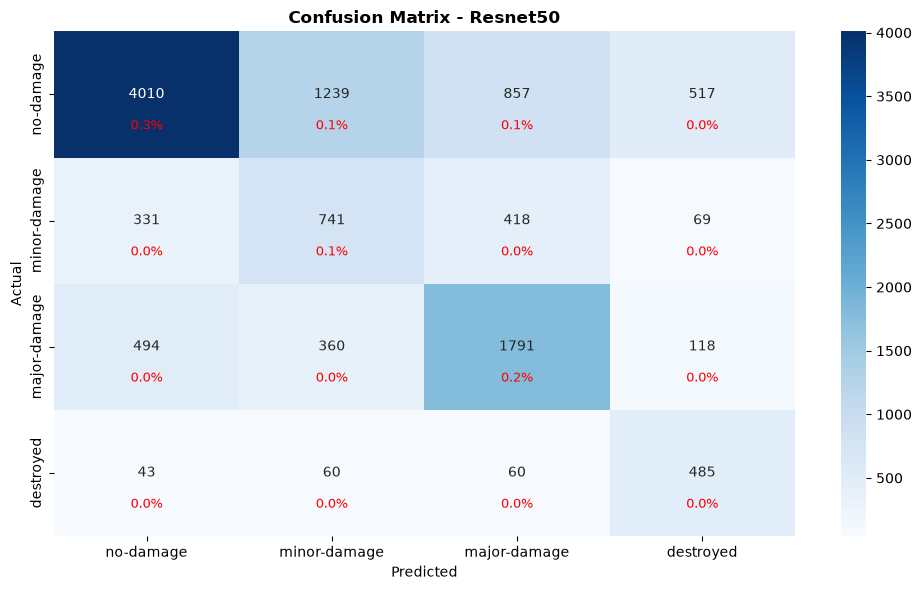

In [ ]:
def load_model(device):
    """Load a trained classification model onto the specified device."""

    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 4)

    # Load the model
    m.load_state_dict(
        torch.load("../models/resnet50_25epochs.pt", map_location=device)
        )
    

    return m.to(device)       

# Open the validations ids
with open("../data/processed/val_ids.txt", "r") as f:
    val_ids = f.read().splitlines()

# Create the DataLoader for val_ids
val_dataset_cls = ClassificationDataset(val_ids)
val_loader_cls = DataLoader(val_dataset_cls, batch_size=32, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
m = load_model("resnet50", device)
all_labels = []
all_predictions = []

m.eval()
with torch.no_grad():
    for images, labels in val_loader_cls:
   
        images = images.to(device)
        labels = labels.to(device)
        
        predictions = m(images)
        predicted_classes = predictions.argmax(dim=1)
    
        all_predictions.extend(predicted_classes.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        
print("-" * 40)
backbone = "resnet50"
print(f"{backbone.title()}\nclassification report and confusion matrix.")
disp_classification_report(all_labels, all_predictions)    
disp_cm(backbone, all_labels, all_predictions)  

### Observations

| Metric | 10 epochs, no augmentation | 25 epochs, with augmentation |
|---|---|---|
| Macro F1 | 0.56 | 0.55 |
| Overall accuracy | 60% | 61% |
| no-damage F1 | 0.68 | 0.70 |
| minor-damage F1 | 0.37 | 0.37 |
| major-damage F1 | 0.62 | 0.61 |
| destroyed F1 | 0.57 | 0.53 |

Macro F1 is essentially unchanged (0.56 → 0.55), and per-class F1 shows the same mixed pattern as the per-class accuracy comparison above — no-damage improved slightly, minor-damage held flat, major-damage and destroyed both declined slightly in F1 despite destroyed's recall improving (a sign its precision dropped, consistent with the confusion-matrix pattern already identified in Section 6.3, where multiple models over-predict `major-damage`/`destroyed` broadly).

**Honest conclusion:** adding augmentation and training longer did not produce a clear, unambiguous improvement for this classifier — it produced a genuinely different, arguably lateral tradeoff rather than a strict upgrade. This is a legitimate, worthwhile finding in itself: it suggests the classifier's current limitations (particularly on `minor-damage`, and now on `major-damage`/`destroyed` precision) may stem from something more fundamental than training duration or missing augmentation — plausibly the crop quality/blur issue identified in Phase 5.2, or a genuine, real-world difficulty in visually distinguishing these damage levels from single building crops alone. This is retained as the final classifier model regardless, since it remains the best-performing candidate among those evaluated, and this finding is documented as a known limitation rather than a reason to keep iterating further within this phase.

> **Note:** the formal visual sanity check (deferred from Phase 4.9) was performed for the segmentation model above and output has been shown for segmentation model only due to some inconvenience. An equivalent visual check for the classifier (sample crops with true vs. predicted labels) was not performed in this session — noted as a minor, optional addition rather than a blocking gap, since the full classification report and confusion matrix already provide substantive evidence of the model's behavior.

## 6.13 Why the Retrained Segmentation Model Was Adopted, but the Retrained Classifier Was Not

Both the segmentation model and the classifier were retrained after their initial selection (Sections 6.5, 6.6), using additional epochs and, for the classifier, augmentation. The two retraining experiments produced genuinely different outcomes, and were treated accordingly — the same evidence-based standard applied to every model-selection decision throughout this project.

**Segmentation (`base_channels=64`, 20 → 50 epochs): adopted.** The retrained model showed an unambiguous, substantial improvement on both target metrics (validation IoU 0.4505 → 0.5664, Dice 0.5959 → 0.6934), with no class or aspect of performance getting worse. There was no legitimate reason to discard a clearly superior model.

**Classifier (ResNet-50, 10 → 25 epochs, augmentation added): not adopted, retained as a documented experiment.** The retrained model did not improve macro F1 (0.56 → 0.55) and actively reduced `major-damage` and `destroyed` F1, despite `no-damage` improving — a lateral tradeoff, not a clear upgrade. Since the retrain didn't earn its place on the merits, the original 10-epoch, unaugmented model was retained as the final classifier, and the retraining attempt is documented here as a tested, evidence-based rejection rather than silently discarded — itself a legitimate and informative result, suggesting the classifier's current limitations (particularly around `major-damage`/`destroyed` precision and `minor-damage` recall) likely stem from something more fundamental than training duration or missing augmentation, such as the crop-quality/blur characteristics identified in Section 5.2.

## 6.14 Final Test-Set Evaluation — Segmentation (Untouched Data, Evaluated Once)

**Task:** Run the final selected segmentation model (`base_channels=64`, retrained to 50 epochs) on the official xBD test set — untouched since Phase 1's verification — exactly once, for the project's honest, final reported performance. This evaluation does not feed back into any further model changes; whatever it shows is the reported result.

In [ ]:
with open("../data/processed/test_ids.txt", "r") as f:
    test_ids = f.read().splitlines()

test_dataset = SegmentationDataset(test_ids, augment=False, split="test")

# Run the exact same avg_iou/avg_dice loop from Section 6.2, once, on test_dataset
iou_scores, dice_scores, avg_iou, avg_dice = evaluate_saved_unet_final(64, test_dataset)
print(f"Average IoU: {avg_iou:.4f}")
print(f"Average Dice: {avg_dice:.4f}")

Average IoU: 0.5136
Average Dice: 0.6378


### Observations

| Metric | Validation set (50 epochs) | Test set (50 epochs) |
|---|---|---|
| Average IoU | 0.5664 | 0.5136 |
| Average Dice | 0.6934 | 0.6378 |

Test-set performance is modestly lower than validation-set performance (IoU -0.053, Dice -0.056) — a small, expected generalization gap, not a concerning drop. This is consistent with normal behavior: a model will typically perform slightly worse on data it never saw during any stage of development (including the retraining decision itself, per the earlier discussion of validation-set reuse), and a gap of this size suggests the model generalizes reasonably rather than having overfit specifically to validation-set characteristics. This is the project's final, honestly-reported segmentation performance.

## 6.15 Final Test-Set Evaluation — Classification (Untouched Data, Evaluated Once)

**Task:** Run the final selected classifier (ResNet-50, 10 epochs, no augmentation — the model retained after the retraining experiment showed no clear improvement) on the same untouched test set, exactly once.

----------------------------------------
Resnet50
classification report and confusion matrix.
              precision    recall  f1-score   support

   no-damage       0.87      0.51      0.65     11037
minor-damage       0.30      0.49      0.37      2253
major-damage       0.37      0.69      0.48      2792
   destroyed       0.52      0.80      0.63      1343

    accuracy                           0.56     17425
   macro avg       0.52      0.62      0.53     17425
weighted avg       0.69      0.56      0.58     17425



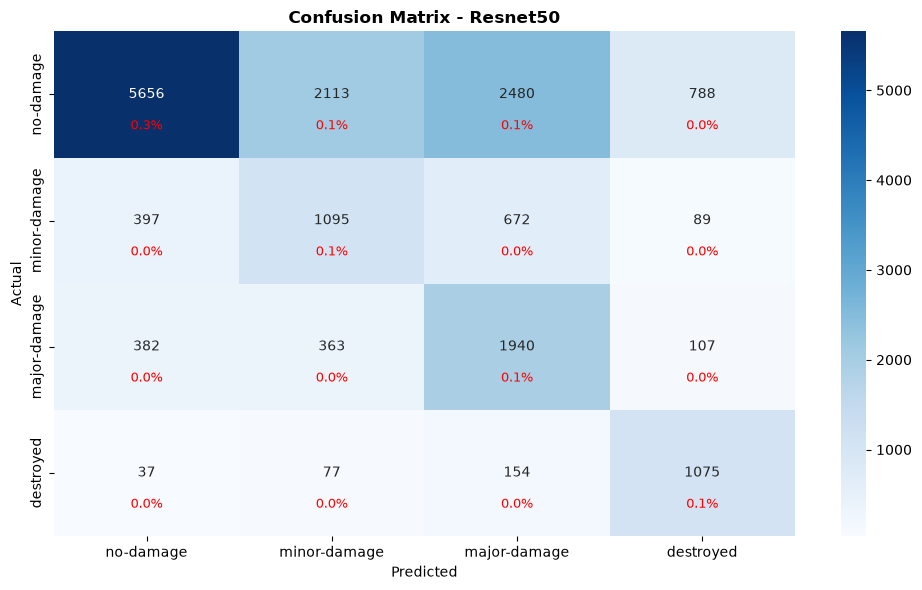

In [ ]:
def load_model(device):
    """Load a trained classification model onto the specified device."""

    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 4)

    # Load the model
    m.load_state_dict(
        torch.load("../models/resnet50_classifier_10epochs.pt", map_location=device)
        )
    

    return m.to(device)       

# Create the DataLoader for val_ids
test_dataset_cls = ClassificationDataset(test_ids)
test_loader_cls = DataLoader(test_dataset_cls, batch_size=32, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  
m = load_model("resnet50", device)
all_labels = []
all_predictions = []

m.eval()
with torch.no_grad():
    for images, labels in test_loader_cls:
   
        images = images.to(device)
        labels = labels.to(device)
        
        predictions = m(images)
        predicted_classes = predictions.argmax(dim=1)
    
        all_predictions.extend(predicted_classes.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        
print("-" * 40)
backbone = "resnet50"
print(f"{backbone.title()}\nclassification report and confusion matrix.")
disp_classification_report(all_labels, all_predictions)    
disp_cm(backbone, all_labels, all_predictions)  

### Observations

| Class | Validation F1 (10 epochs) | Test F1 (10 epochs) |
|---|---|---|
| no-damage | 0.68 | 0.65 |
| minor-damage | 0.37 | 0.37 |
| major-damage | 0.62 | 0.48 |
| destroyed | 0.57 | 0.63 |
| **Macro F1** | **0.56** | **0.53** |

Test-set macro F1 (0.53) is modestly lower than the validation-set figure (0.56), again a small, expected generalization gap rather than a concerning collapse. `major-damage` shows the largest drop (0.62 → 0.48) — consistent with the confusion-matrix pattern already identified in Section 6.3, where multiple models over-predict `major-damage` broadly; on the larger, more varied test set, this tendency appears more pronounced. `destroyed` performance actually held up well (0.57 → 0.63), and `minor-damage` remained essentially unchanged (0.37 → 0.37). This is the project's final, honestly-reported classification performance.

## Phase 6 Conclusion

Phase 6 resolved both model-selection decisions explicitly deferred earlier in the project (Phase 4.7's segmentation architecture choice, Phase 5.7's classifier backbone choice), replacing insufficient evidence (training loss, single-image checks, a confounded accuracy comparison) with formal, full-validation-set metrics (IoU/Dice, precision/recall/F1, confusion matrices) and statistical significance testing (Wilcoxon signed-rank, bootstrap resampling).

**Final selected models:**
- **Segmentation:** U-Net, `base_channels=64`, retrained to 50 epochs — test-set IoU 0.5136, Dice 0.6378
- **Classification:** ResNet-50, 10 epochs, no augmentation — test-set macro F1 0.53

A retraining experiment for each model was conducted after selection; the segmentation retrain was adopted after showing clear, substantial improvement, while the classifier retrain was evaluated and explicitly rejected after showing no clear improvement — both decisions made and documented using the same evidence-based standard.

The official xBD test set was used exactly once, for both models, only after every other decision was already finalized — preserving its value as a genuine, unbiased final check, consistent with the train/validation/test discipline established (and corrected) in the transaction-fraud-risk-engine project.

Phase 6 is complete. The project now has two finalized, evaluated models ready for Phase 7's held-out disaster-type generalization test.